In [98]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier


In [ ]:
#LOAD DATASET

df = pd.read_csv("6_wines.csv")

# Q1. Exploratory Data Analysis

### Dataset Overview: Size (rows and columns), attributes, attribute types (continuous, categorical, discrete), statistical summary, class distribution

                  1. DATASET SIZE
  Rows             : 7500
  Columns          : 11
  Total Cells      : 82500
  Duplicate Rows   : 5452
  Memory Usage     : 3187.47 KB

                  2. ATTRIBUTES & TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       7499 non-null   object 
 1   wine         7499 non-null   object 
 2   year         7495 non-null   object 
 3   rating       7500 non-null   float64
 4   num_reviews  7497 non-null   float64
 5   country      7499 non-null   object 
 6   region       7497 non-null   object 
 7   price        7500 non-null   float64
 8   type         6952 non-null   object 
 9   body         6331 non-null   float64
 10  acidity      6331 non-null   float64
dtypes: float64(5), object(6)
memory usage: 644.7+ KB

            3. CONTINUOUS / DISCRETE / CATEGORICAL

  Continuous  (2) : ['num_revi

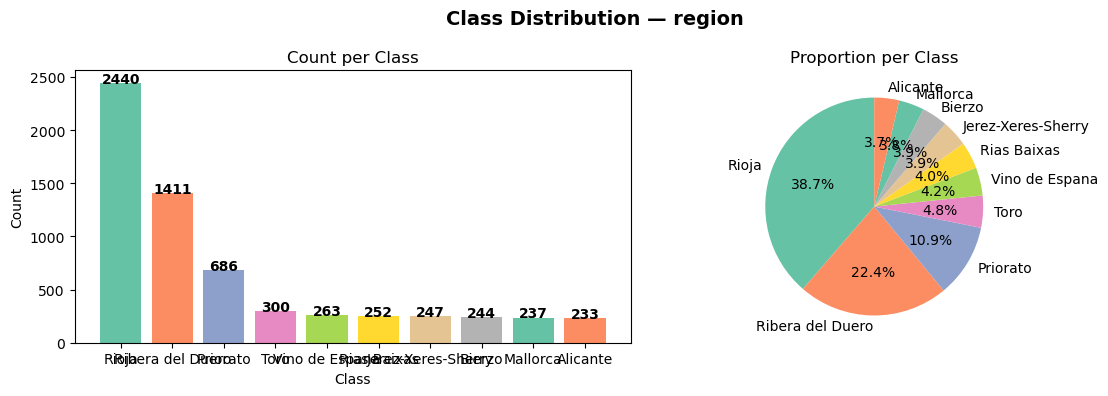

In [18]:
#SIZE 
print("=" * 60)
print("                  1. DATASET SIZE")
print("=" * 60)
print(f"  Rows             : {df.shape[0]}")
print(f"  Columns          : {df.shape[1]}")
print(f"  Total Cells      : {df.shape[0] * df.shape[1]}")
print(f"  Duplicate Rows   : {df.duplicated().sum()}")
print(f"  Memory Usage     : {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

#ATTRIBUTES 
print("\n" + "=" * 60)
print("                  2. ATTRIBUTES & TYPES")
print("=" * 60)
df.info()

#CLASSIFY ATTRIBUTES 
print("\n" + "=" * 60)
print("            3. CONTINUOUS / DISCRETE / CATEGORICAL")
print("=" * 60)

numeric_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
categorical    = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

continuous = []
discrete   = []

for col in numeric_cols:
    unique_ratio = df[col].nunique() / len(df)
    if df[col].nunique() <= 15 or unique_ratio < 0.05:   # tweak threshold if needed
        discrete.append(col)
    else:
        continuous.append(col)

print(f"\n  Continuous  ({len(continuous)}) : {continuous}")
print(f"  Discrete    ({len(discrete)})  : {discrete}")
print(f"  Categorical ({len(categorical)}): {categorical}")

#STATISTICAL SUMMARY 
print("\n" + "=" * 60)
print("              4. STATISTICAL SUMMARY (Numeric)")
print("=" * 60)
print(df.describe(include=[np.number]).T.to_string())

print("\n" + "-" * 60)
print("           STATISTICAL SUMMARY (Categorical)")
print("-" * 60)
if categorical:
    print(df[categorical].describe().T.to_string())

#CLASS DISTRIBUTION

target_col = 'region'

if target_col in df.columns:
    print("\n" + "=" * 60)
    print(f"         5. CLASS DISTRIBUTION  →  '{target_col}'")
    print("=" * 60)

    counts = df[target_col].value_counts().head(10)
    props  = df[target_col].value_counts(normalize=True).head(10) * 100

    dist_df = pd.DataFrame({'Count': counts, 'Percentage (%)': props.round(2)})
    print(dist_df.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Class Distribution — {target_col}', fontsize=14, fontweight='bold')

    #BAR CHART
    axes[0].bar(counts.index.astype(str), counts.values,
                color=sns.color_palette('Set2', len(counts)))
    axes[0].set_title('Count per Class')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    #PIE CHART
    axes[1].pie(counts.values, labels=counts.index.astype(str),
                autopct='%1.1f%%', colors=sns.color_palette('Set2', len(counts)),
                startangle=90)
    axes[1].set_title('Proportion per Class')

    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150)
    plt.show()
else:
    print(f"\n   Column '{target_col}' not found. Update target_col variable.")

### Dispersion analysis, skewness, and outlier detection by showing their indices

                    1. DISPERSION ANALYSIS
                 Mean  Median   Std Dev     Variance    Min       Max     Range      IQR  CV (%)
rating         4.2549    4.20    0.1180       0.0139   4.20      4.90      0.70   0.0000    2.77
num_reviews  451.1829  404.00  722.9848  522707.0664  25.00  32624.00  32599.00  26.0000  160.24
price         60.0958   28.53  150.3567   22607.1302   4.99   3119.08   3114.09  32.4500  250.19
body           4.1584    4.00    0.5360       0.2873   2.00      5.00      3.00   0.1584   12.89
acidity        2.9549    3.00    0.2289       0.0524   1.00      3.00      2.00   0.0000    7.74

                    2. SKEWNESS ANALYSIS
              Skewness    Kurtosis           Interpretation
rating        2.443475    5.674024     Highly Positive Skew
num_reviews  17.857037  596.932282     Highly Positive Skew
price         9.643682  123.811698     Highly Positive Skew
body         -0.216579    1.124855  Approximately Symmetric
acidity      -5.499548   32.71217

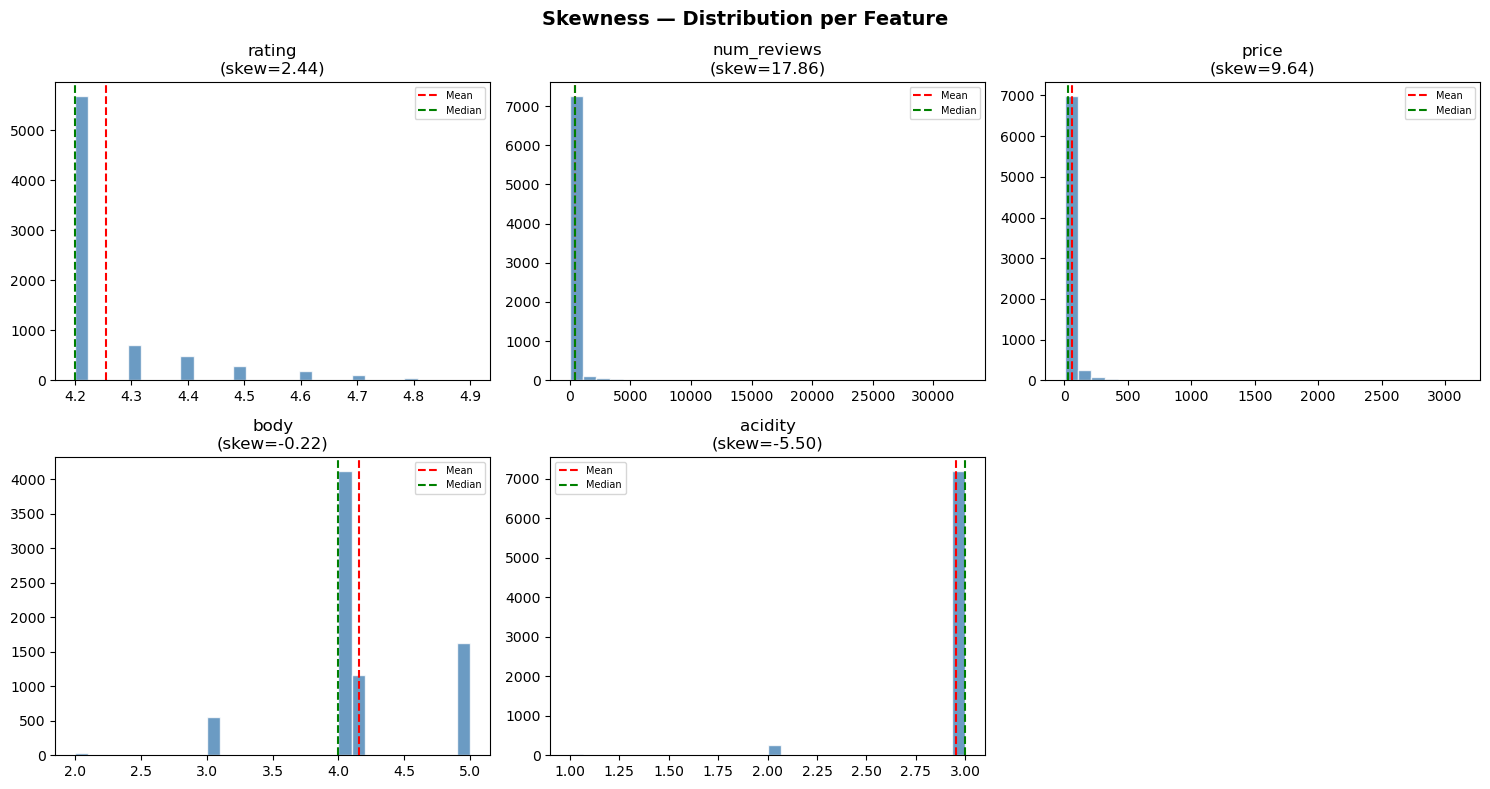


             3. OUTLIER DETECTION (IQR + Z-Score)

  Feature : rating
    IQR   → 1821 outliers | Bounds [4.200, 4.200]
            Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 19

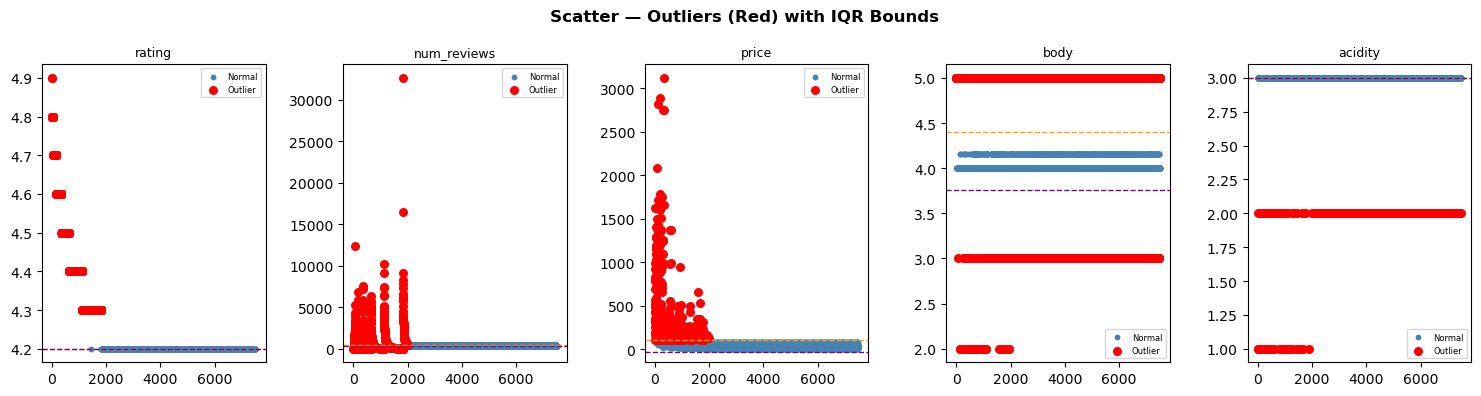


                  OUTLIER SUMMARY TABLE
    Feature  IQR Outlier Count  IQR Lower Bound  IQR Upper Bound  Z-Score Count
     rating               1821           4.2000           4.2000            158
num_reviews               1917         350.0000         454.0000            110
      price                538         -29.7750         100.0250            109
       body               2211           3.7624           4.3961             34
    acidity                303           3.0000           3.0000            303


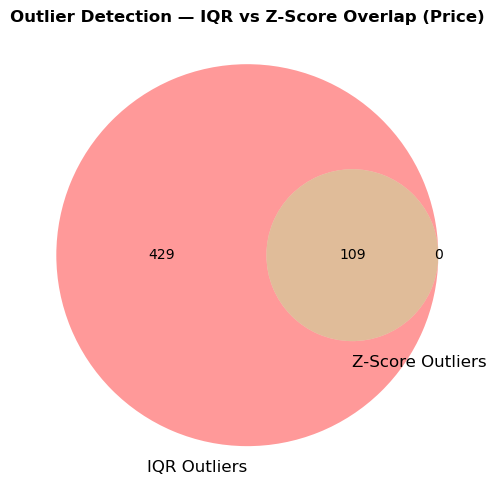

IQR only    : 429
Z-Score only: 0
Both        : 109


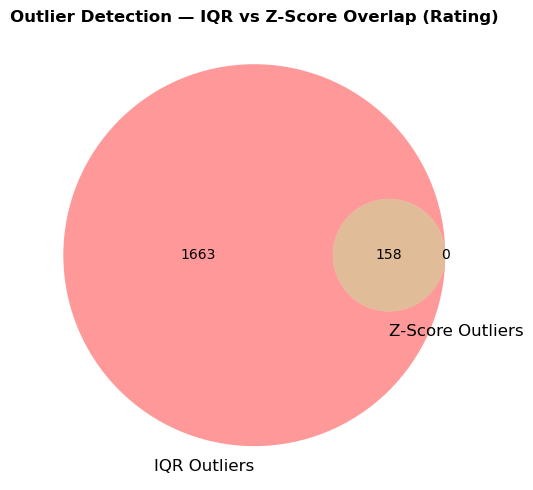

IQR only    : 1663
Z-Score only: 0
Both        : 158


In [103]:
#DISPERSION ANALYSIS 
print("=" * 60)
print("                    1. DISPERSION ANALYSIS")
print("=" * 60)

dispersion = pd.DataFrame({
    'Mean'     : df[numeric_cols].mean(),
    'Median'   : df[numeric_cols].median(),
    'Std Dev'  : df[numeric_cols].std(),
    'Variance' : df[numeric_cols].var(),
    'Min'      : df[numeric_cols].min(),
    'Max'      : df[numeric_cols].max(),
    'Range'    : df[numeric_cols].max() - df[numeric_cols].min(),
    'IQR'      : df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25),
    'CV (%)'   : (df[numeric_cols].std() / df[numeric_cols].mean() * 100).round(2)
})

print(dispersion.round(4).to_string())

#SKEWNESS ANALYSIS 
print("\n" + "=" * 60)
print("                    2. SKEWNESS ANALYSIS")
print("=" * 60)

skew_df = pd.DataFrame({
    'Skewness' : df[numeric_cols].skew(),
    'Kurtosis' : df[numeric_cols].kurt()
})

def skew_label(s):
    if   s > 1  : return 'Highly Positive Skew'
    elif s > 0.5: return 'Moderate Positive Skew'
    elif s < -1 : return 'Highly Negative Skew'
    elif s < -0.5: return 'Moderate Negative Skew'
    else        : return 'Approximately Symmetric'

skew_df['Interpretation'] = skew_df['Skewness'].apply(skew_label)
print(skew_df.to_string())

#SKEWNESS PLOT
n_cols  = 3
n_rows  = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green',  linestyle='--', label='Median')
    axes[i].set_title(f'{col}\n(skew={df[col].skew():.2f})')
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Skewness — Distribution per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('skewness.png', dpi=150)
plt.show()

#OUTLIER DETECTION 
print("\n" + "=" * 60)
print("             3. OUTLIER DETECTION (IQR + Z-Score)")
print("=" * 60)

outlier_summary = []

for col in numeric_cols:
    series = df[col].dropna()

    #IQR 
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    iqr_mask     = (df[col] < lower) | (df[col] > upper)
    iqr_indices  = df.index[iqr_mask].tolist()

    #Z-SCORE
    z_scores     = np.abs(stats.zscore(series))
    z_outlier_idx = series.index[z_scores > 3].tolist()

    outlier_summary.append({
        'Feature'           : col,
        'IQR Outlier Count' : len(iqr_indices),
        'IQR Lower Bound'   : round(lower, 4),
        'IQR Upper Bound'   : round(upper, 4),
        'IQR Indices'       : iqr_indices[:20],       
        'Z-Score Count'     : len(z_outlier_idx),
        'Z-Score Indices'   : z_outlier_idx[:20]
    })

    print(f"\n  Feature : {col}")
    print(f"    IQR   → {len(iqr_indices)} outliers | Bounds [{lower:.3f}, {upper:.3f}]")
    print(f"            Indices: {iqr_indices}")
    print(f"    Z-Score → {len(z_outlier_idx)} outliers (|z| > 3)")
    print(f"            Indices: {z_outlier_idx}")

#SCATTER PLOT 
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    Q1, Q3   = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR      = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    is_out   = (df[col] < lower) | (df[col] > upper)

    axes[i].scatter(df.index[~is_out], df[col][~is_out],
                    color='steelblue', s=10, label='Normal')
    axes[i].scatter(df.index[is_out],  df[col][is_out],
                    color='red', s=30, label='Outlier')
    axes[i].axhline(upper, color='orange', linestyle='--', linewidth=1)
    axes[i].axhline(lower, color='purple', linestyle='--', linewidth=1)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=6)

plt.suptitle('Scatter — Outliers (Red) with IQR Bounds', fontweight='bold')
plt.tight_layout()
plt.show()

#SUMMARY
print("\n" + "=" * 60)
print("                  OUTLIER SUMMARY TABLE")
print("=" * 60)
summary_df = pd.DataFrame(outlier_summary)[
    ['Feature', 'IQR Outlier Count', 'IQR Lower Bound', 'IQR Upper Bound', 'Z-Score Count']
]
print(summary_df.to_string(index=False))

#VENN DIAGRAM PRICE
Q1, Q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
IQR    = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

iqr_set = set(df.index[(df['price'] < lower) | (df['price'] > upper)])
z_scores = np.abs(stats.zscore(df['price'].dropna()))
z_set    = set(df['price'].dropna().index[z_scores > 3])

plt.figure(figsize=(7, 5))
venn2([iqr_set, z_set], set_labels=('IQR Outliers', 'Z-Score Outliers'))
plt.title('Outlier Detection — IQR vs Z-Score Overlap (Price)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"IQR only    : {len(iqr_set - z_set)}")
print(f"Z-Score only: {len(z_set - iqr_set)}")
print(f"Both        : {len(iqr_set & z_set)}")

#VENN DIAGRAM RATING
Q1, Q3 = df['rating'].quantile(0.25), df['rating'].quantile(0.75)
IQR    = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

iqr_set = set(df.index[(df['rating'] < lower) | (df['rating'] > upper)])
z_scores = np.abs(stats.zscore(df['rating'].dropna()))
z_set    = set(df['rating'].dropna().index[z_scores > 3])

plt.figure(figsize=(7, 5))
venn2([iqr_set, z_set], set_labels=('IQR Outliers', 'Z-Score Outliers'))
plt.title('Outlier Detection — IQR vs Z-Score Overlap (Rating)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"IQR only    : {len(iqr_set - z_set)}")
print(f"Z-Score only: {len(z_set - iqr_set)}")
print(f"Both        : {len(iqr_set & z_set)}")



### Missing Values: Count per feature, deal with missing values using mechanism (MCAR/MAR/MNAR), provide justification for appropriate Imputation method(s)

             Missing Count  Missing (%) Data Type  Non-Null Count
body                  1169        15.59   float64            6331
acidity               1169        15.59   float64            6331
type                   548         7.31    object            6952
year                     5         0.07    object            7495
num_reviews              3         0.04   float64            7497
region                   3         0.04    object            7497
winery                   1         0.01    object            7499
country                  1         0.01    object            7499
wine                     1         0.01    object            7499

  Total missing cells : 2900
  Total missing (%)   : 3.52%


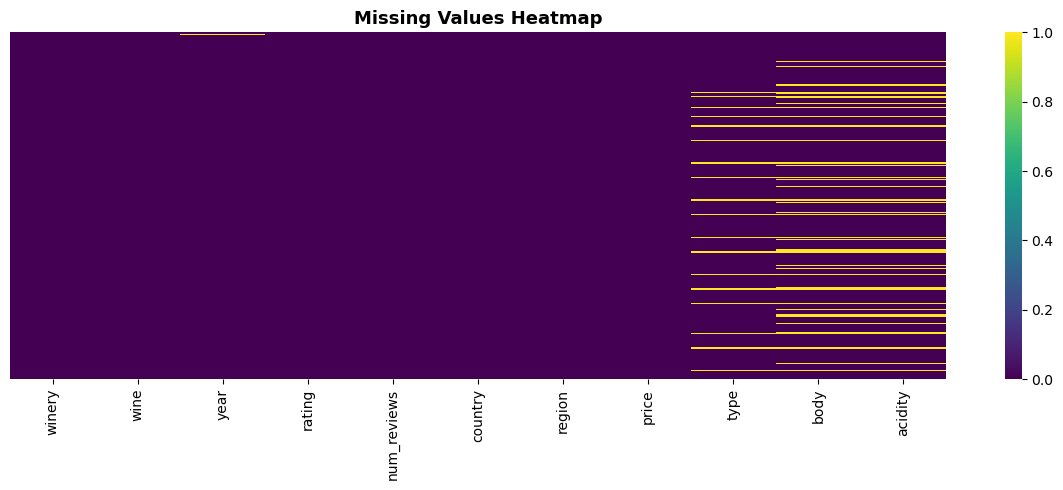

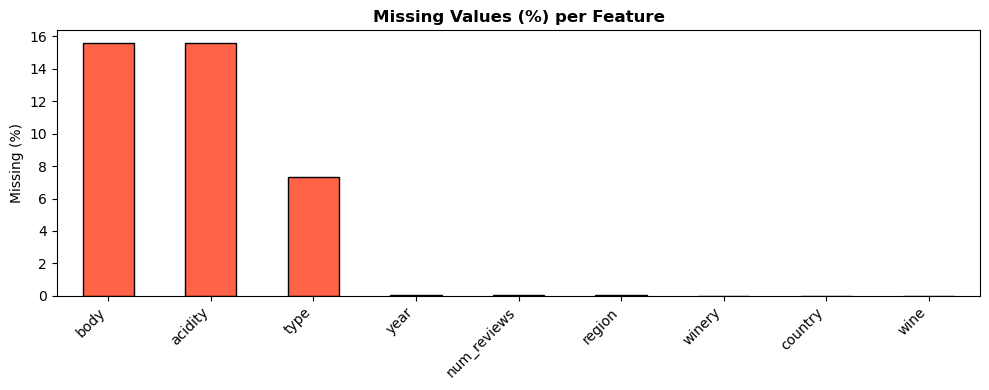


        2. MISSING DATA MECHANISM (MCAR / MAR / MNAR)

  MCAR (Missing Completely At Random)
  ─────────────────────────────────────────────────────────────
  • Missingness is unrelated to any variable (observed or not).
  • Test : Little's MCAR test (p > 0.05 → cannot reject MCAR).
  • Sign : Missing data appears randomly across all features.

  MAR (Missing At Random)
  ─────────────────────────────────────────────────────────────
  • Missingness depends on OTHER observed variables, not itself.
  • Test : Compare missing vs non-missing groups with t-test /
           chi-square on other features.
  • Sign : Correlation found between missingness and another col.

  MNAR (Missing Not At Random)
  ─────────────────────────────────────────────────────────────
  • Missingness depends on the unobserved value itself.
  • No statistical test can confirm this — requires domain knowledge.
  • Sign : Extreme values tend to be missing (e.g., high income
           people skip income field).

--

C:\Users\renat\AppData\Local\Temp\ipykernel_14116\3090321925.py:118: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(fill_val, inplace=True)
C:\Users\renat\AppData\Local\Temp\ipykernel_14116\3090321925.py:111: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [20]:
missing = pd.DataFrame({
    'Missing Count'  : df.isnull().sum(),
    'Missing (%)'    : (df.isnull().mean() * 100).round(2),
    'Data Type'      : df.dtypes,
    'Non-Null Count' : df.notnull().sum()
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

if missing.empty:
    print("  ✅ No missing values found in the dataset.")
else:
    print(missing.to_string())
    print(f"\n  Total missing cells : {df.isnull().sum().sum()}")
    print(f"  Total missing (%)   : {df.isnull().mean().mean() * 100:.2f}%")

#HEATMAP
    plt.figure(figsize=(12, 5))
    sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
    plt.title('Missing Values Heatmap', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('missing_heatmap.png', dpi=150)
    plt.show()

#BAR CHART
    plt.figure(figsize=(10, 4))
    missing['Missing (%)'].plot(kind='bar', color='tomato', edgecolor='black')
    plt.title('Missing Values (%) per Feature', fontweight='bold')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('missing_bar.png', dpi=150)
    plt.show()

#MECHANISM DETECTION
print("\n" + "=" * 60)
print("        2. MISSING DATA MECHANISM (MCAR / MAR / MNAR)")
print("=" * 60)

print("""
  MCAR (Missing Completely At Random)
  ─────────────────────────────────────────────────────────────
  • Missingness is unrelated to any variable (observed or not).
  • Test : Little's MCAR test (p > 0.05 → cannot reject MCAR).
  • Sign : Missing data appears randomly across all features.

  MAR (Missing At Random)
  ─────────────────────────────────────────────────────────────
  • Missingness depends on OTHER observed variables, not itself.
  • Test : Compare missing vs non-missing groups with t-test /
           chi-square on other features.
  • Sign : Correlation found between missingness and another col.

  MNAR (Missing Not At Random)
  ─────────────────────────────────────────────────────────────
  • Missingness depends on the unobserved value itself.
  • No statistical test can confirm this — requires domain knowledge.
  • Sign : Extreme values tend to be missing (e.g., high income
           people skip income field).
""")

#AUTO CORRELATION CHECK
print("-" * 60)
print("  Correlation of Missingness Indicators with Other Features")
print("-" * 60)

cols_with_missing = df.columns[df.isnull().any()].tolist()
numeric_cols      = df.select_dtypes(include=[np.number]).columns.tolist()

for col in cols_with_missing:
    missing_indicator = df[col].isnull().astype(int)
    print(f"\n  Feature: {col}")
    for other in numeric_cols:
        if other != col and df[other].notnull().any():
            corr, pval = stats.pointbiserialr(missing_indicator, df[other].fillna(df[other].median()))
            if abs(corr) > 0.1:
                print(f"    ↳ corr with '{other}': r={corr:.3f}, p={pval:.4f} "
                      f"{'← possible MAR' if pval < 0.05 else ''}")

#IMPUTATION 
print("\n" + "=" * 60)
print("          3. IMPUTATION METHODS WITH JUSTIFICATION")
print("=" * 60)

df_imputed = df.copy()

for col in cols_with_missing:
    dtype       = df[col].dtype
    skewness    = df[col].skew() if col in numeric_cols else None
    pct_missing = df[col].isnull().mean() * 100

    print(f"\n  ── {col} ──")
    print(f"     Missing: {pct_missing:.1f}%  |  dtype: {dtype}", end="")
    if skewness is not None:
        print(f"  |  skewness: {skewness:.2f}")
    else:
        print()

    #NUMERIC
    if col in numeric_cols:
        if abs(skewness) > 1:
            fill_val = df[col].median()
            method   = 'Median'
            reason   = ('Distribution is highly skewed — median is robust '
                        'to outliers and better represents central tendency.')
        else:
            fill_val = df[col].mean()
            method   = 'Mean'
            reason   = ('Distribution is approximately symmetric — mean '
                        'is the optimal estimator for central tendency.')

        df_imputed[col].fillna(fill_val, inplace=True)
        print(f"     Method : {method} imputation  (fill value = {fill_val:.4f})")
        print(f"     Why    : {reason}")

    #CATEGORICAL
    else:
        fill_val = df[col].mode()[0]
        df_imputed[col].fillna(fill_val, inplace=True)
        print(f"     Method : Mode imputation  (fill value = '{fill_val}')")
        print(f"     Why    : Categorical feature — mode preserves the most "
              f"frequent category without introducing unseen labels.")

#BEFORE / AFTER SUMMARY 
print("\n" + "=" * 60)
print("              4. BEFORE vs AFTER IMPUTATION")
print("=" * 60)
before_after = pd.DataFrame({
    'Before (missing)' : df.isnull().sum(),
    'After  (missing)' : df_imputed.isnull().sum()
})
print(before_after[before_after['Before (missing)'] > 0].to_string())
print(f"\n  Remaining missing values: {df_imputed.isnull().sum().sum()}")

#SAVE
df_imputed.to_csv('6_wines_clean.csv', index=False)
print("  Clean dataset saved → '6_wines_clean.csv'")

# Q2. Feature Selection and Reduction

In [41]:
#LOAD IMPUTED DF
df = pd.read_csv('6_wines_clean.csv')

In [42]:
print(df.isnull().sum())

winery         0
wine           0
year           0
rating         0
num_reviews    0
country        0
region         0
price          0
type           0
body           0
acidity        0
dtype: int64


### Show feature correlations in your data (like correlation matrix heatmap) (10)


In [44]:
df_encoded = df.copy()

df_encoded = df_encoded.drop(columns=['country'])

for col in df_encoded.select_dtypes(include=['object', 'category', 'bool']).columns:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

corr = df_encoded.corr().round(3)

corr.style.background_gradient(cmap='coolwarm')

,winery,wine,year,rating,num_reviews,region,price,type,body,acidity
winery,1.000000,0.681000,0.338000,-0.311000,-0.067000,0.443000,-0.232000,0.197000,-0.127000,0.196000
wine,0.681000,1.000000,0.161000,-0.422000,-0.046000,0.351000,-0.279000,0.249000,-0.219000,0.147000
year,0.338000,0.161000,1.000000,0.007000,-0.023000,0.272000,0.035000,-0.036000,0.009000,0.018000
rating,-0.311000,-0.422000,0.007000,1.000000,0.016000,-0.081000,0.545000,-0.098000,0.158000,-0.099000
num_reviews,-0.067000,-0.046000,-0.023000,0.016000,1.000000,-0.062000,-0.030000,-0.059000,0.063000,0.039000
region,0.443000,0.351000,0.272000,-0.081000,-0.062000,1.000000,-0.125000,0.387000,-0.367000,0.125000
price,-0.232000,-0.279000,0.035000,0.545000,-0.030000,-0.125000,1.000000,-0.110000,0.153000,-0.040000
type,0.197000,0.249000,-0.036000,-0.098000,-0.059000,0.387000,-0.110000,1.000000,-0.741000,0.219000
body,-0.127000,-0.219000,0.009000,0.158000,0.063000,-0.367000,0.153000,-0.741000,1.000000,-0.018000
acidity,0.196000,0.147000,0.018000,-0.099000,0.039000,0.125000,-0.040000,0.219000,-0.018000,1.000000


### Construct new feature(s) from the given ones (5)


In [51]:

#WINE AGE
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['wine_age'] = 2024 - df['year']

#PRICE PER RATING
df['price_per_rating'] = df['price'] / df['rating']

#WEIGHTED SCORE
df['weighted_score'] = df['rating'] * np.log1p(df['num_reviews'])

#PRICE CATEGORY
df['price_category'] = pd.cut(df['price'], bins=3,
                               labels=['Budget', 'Mid-Range', 'Premium'])

print("NEW FEATURES ADDED")
print(df[['wine', 'year', 'wine_age',
          'price', 'rating',
          'price_per_rating',
          'num_reviews', 'weighted_score',
          'price_category']].head(10))

print("\nDataset shape after feature engineering:", df.shape)

NEW FEATURES ADDED
                             wine    year  wine_age   price  rating  \
0                           Tinto  2013.0      11.0  995.00     4.9   
1                   Vina El Pison  2018.0       6.0  313.50     4.9   
2                           Unico  2009.0      15.0  324.95     4.8   
3                           Unico  1999.0      25.0  692.96     4.8   
4                           Unico  1996.0      28.0  778.06     4.8   
5                           Unico  1998.0      26.0  490.00     4.8   
6                           Unico  2010.0      14.0  349.00     4.8   
7                           Unico  1995.0      29.0  810.89     4.8   
8  Unico Reserva Especial Edicion  2015.0       9.0  345.00     4.8   
9                           Unico  2011.0      13.0  315.00     4.8   

   price_per_rating  num_reviews  weighted_score price_category  
0        203.061224         58.0       19.979933         Budget  
1         63.979592         31.0       16.982106         Budget  
2

### Show top features using feature selection method such as permutationimportance, univariate etc. (5)


TOP FEATURES (F-Score)
       Feature    Score
         price 3164.939
      wine_age  735.240
price_category  608.671
weighted_score  587.504
          body  191.727
       acidity   74.058
        region   15.379
          wine    7.989
        winery    3.909
   num_reviews    1.837
          type    0.442


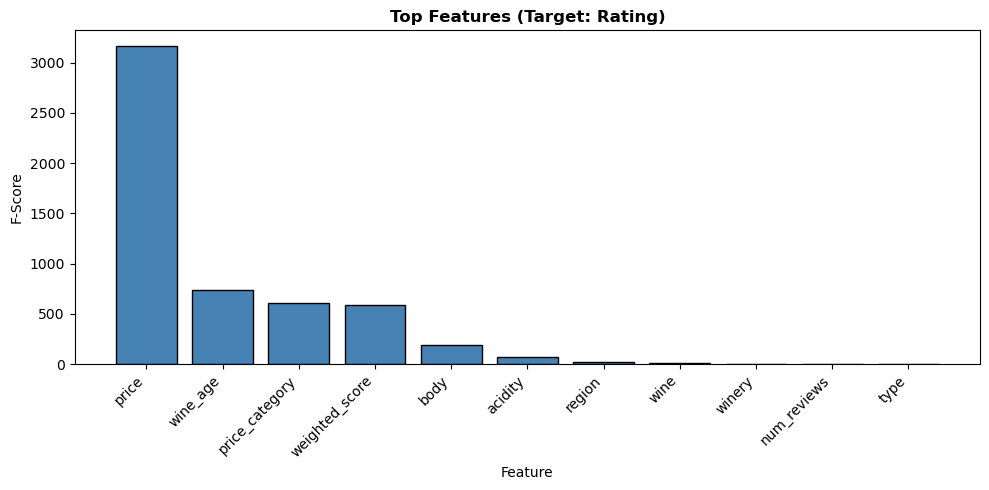

In [63]:
#DROP REPETITIVE VALUES
df_encoded = df.copy().drop(columns=['country','price_per_rating','year'])
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

#TARGET RATING
X = df_encoded.drop(columns=['rating']).fillna(df_encoded.median())
y = df_encoded['rating']

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

scores_df = pd.DataFrame({
    'Feature': X.columns,
    'Score'  : selector.scores_.round(3)
}).sort_values('Score', ascending=False)

print("TOP FEATURES (F-Score)")
print(scores_df.to_string(index=False))

#COLUMN CHART
plt.figure(figsize=(10, 5))
plt.bar(scores_df['Feature'], scores_df['Score'],
        color='steelblue', edgecolor='black')
plt.title('Top Features (Target: Rating)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('F-Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Apply a feature reduction method (SVD/PCA) and present the results using graphs (10)

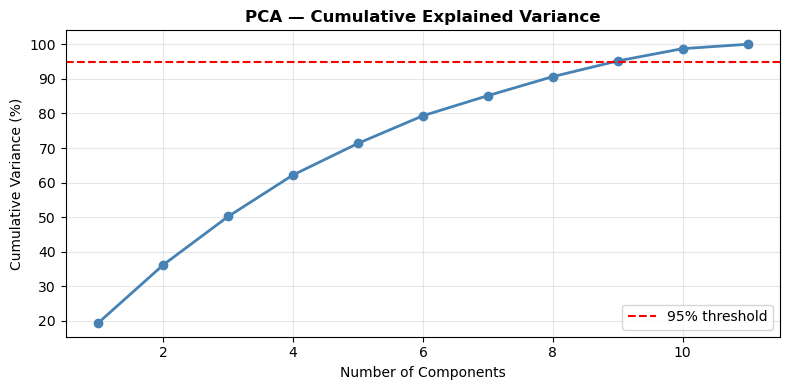

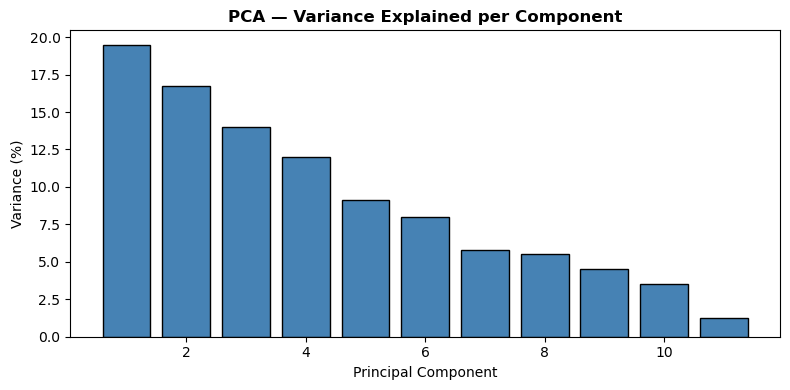

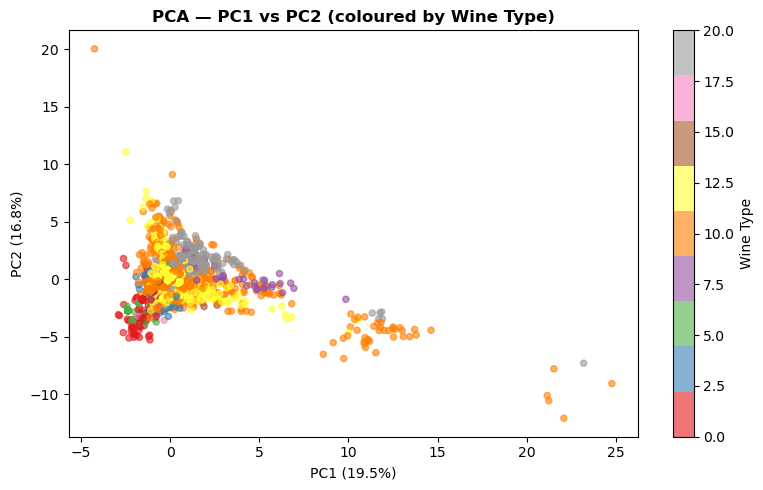

Total features          : 11
Components for 95% var  : 9
PC1 explains            : 19.5%
PC2 explains            : 16.8%


In [64]:

X = df_encoded.drop(columns=['rating']).fillna(df_encoded.median())
y = df_encoded['rating']

#PCA
X_scaled  = StandardScaler().fit_transform(X)
pca       = PCA()
X_pca     = pca.fit_transform(X_scaled)

explained  = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

#LINE CHART
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained) + 1), cumulative,
         marker='o', color='steelblue', linewidth=2)
plt.axhline(95, color='red', linestyle='--', label='95% threshold')
plt.title('PCA — Cumulative Explained Variance', fontweight='bold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#COLUMN CHART
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained) + 1), explained,
        color='steelblue', edgecolor='black')
plt.title('PCA — Variance Explained per Component', fontweight='bold')
plt.xlabel('Principal Component')
plt.ylabel('Variance (%)')
plt.tight_layout()
plt.show()

#SCATTER PLOT
type_encoded = LabelEncoder().fit_transform(df['type'].astype(str))
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=type_encoded, cmap='Set1', s=20, alpha=0.6)
plt.title('PCA — PC1 vs PC2 (coloured by Wine Type)', fontweight='bold')
plt.xlabel(f'PC1 ({explained[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained[1]:.1f}%)')
plt.colorbar(scatter, label='Wine Type')
plt.tight_layout()
plt.show()

#SUMMARY
n_95 = np.argmax(cumulative >= 95) + 1
print(f"Total features          : {X.shape[1]}")
print(f"Components for 95% var  : {n_95}")
print(f"PC1 explains            : {explained[0]:.1f}%")
print(f"PC2 explains            : {explained[1]:.1f}%")

# Q3. Modelling 

### Model1: Suggest and implement pipeline with a baseline model (like simple linear regression for regression task or Naïve Bayes for classification task) (5)


In [82]:
# DROP WARNINGS
import warnings
warnings.filterwarnings('ignore')

X = df_encoded.drop(columns=['rating']).fillna(df_encoded.median())
y = LabelEncoder().fit_transform(df['rating'])

#PIPELINE
model1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GaussianNB())
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results1 = cross_validate(model1, X, y, cv=cv,
                           scoring=['accuracy', 'f1_weighted',
                                    'precision_weighted', 'recall_weighted'])

print("MODEL 1 — Naïve Bayes (Baseline)")
print(f"  Accuracy  : {results1['test_accuracy'].mean():.3f}")
print(f"  F1        : {results1['test_f1_weighted'].mean():.3f}")
print(f"  Precision : {results1['test_precision_weighted'].mean():.3f}")
print(f"  Recall    : {results1['test_recall_weighted'].mean():.3f}")

MODEL 1 — Naïve Bayes (Baseline)
  Accuracy  : 0.796
  F1        : 0.780
  Precision : 0.777
  Recall    : 0.796


### Model2: Suggest pipeline with advanced model (Decision trees, Random Forest, Gradient Boosting etc.) (5)


In [83]:
# DROP WARNINGS
import warnings
warnings.filterwarnings('ignore')

X = df_encoded.drop(columns=['rating']).fillna(df_encoded.median())
y = LabelEncoder().fit_transform(df['rating'])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#PIPELINE
model2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
])

results2 = cross_validate(model2, X, y, cv=cv,
                           scoring=['accuracy', 'f1_weighted',
                                    'precision_weighted', 'recall_weighted'])

print("MODEL 2 — Random Forest (Advanced)")
print(f"  Accuracy  : {results2['test_accuracy'].mean():.3f}")
print(f"  F1        : {results2['test_f1_weighted'].mean():.3f}")
print(f"  Precision : {results2['test_precision_weighted'].mean():.3f}")
print(f"  Recall    : {results2['test_recall_weighted'].mean():.3f}")

MODEL 2 — Random Forest (Advanced)
  Accuracy  : 0.869
  F1        : 0.865
  Precision : 0.865
  Recall    : 0.869


### Contrast the results from your 10-fold CV runs for both models, use appropriate evaluation metrics for regression or classification. (10)

10-FOLD CV RESULTS COMPARISON
   Metric  Naive Bayes  Random Forest
 Accuracy        0.796          0.869
       F1        0.780          0.865
Precision        0.777          0.865
   Recall        0.796          0.869


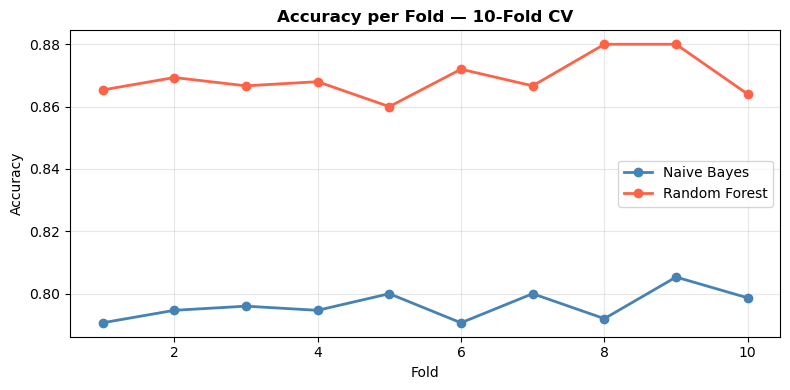

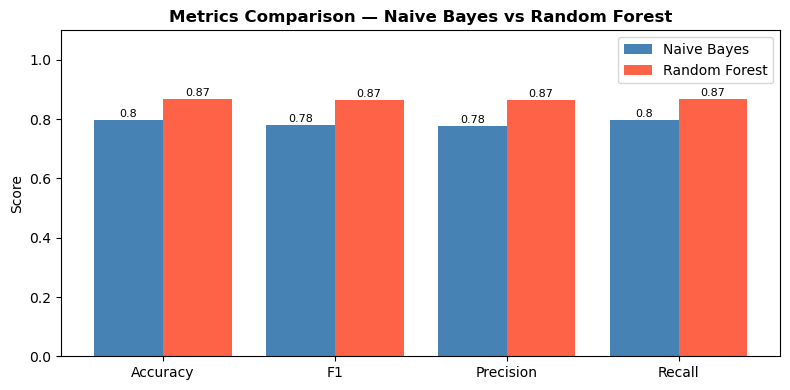

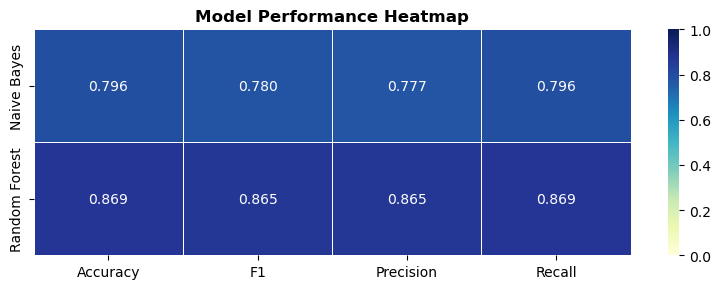

In [96]:
#SUMARRY
summary = pd.DataFrame({
    'Metric'       : ['Accuracy', 'F1', 'Precision', 'Recall'],
    'Naive Bayes'  : [results1['test_accuracy'].mean().round(3),
                      results1['test_f1_weighted'].mean().round(3),
                      results1['test_precision_weighted'].mean().round(3),
                      results1['test_recall_weighted'].mean().round(3)],
    'Random Forest': [results2['test_accuracy'].mean().round(3),
                      results2['test_f1_weighted'].mean().round(3),
                      results2['test_precision_weighted'].mean().round(3),
                      results2['test_recall_weighted'].mean().round(3)]
})
print("10-FOLD CV RESULTS COMPARISON")
print(summary.to_string(index=False))

#LINE CHART ACURRACY
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), results1['test_accuracy'], marker='o',
         label='Naive Bayes', color='steelblue', linewidth=2)
plt.plot(range(1, 11), results2['test_accuracy'], marker='o',
         label='Random Forest', color='tomato', linewidth=2)
plt.title('Accuracy per Fold — 10-Fold CV', fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#COLUMN CHART ALL METRICS
metrics   = ['Accuracy', 'F1', 'Precision', 'Recall']
nb_scores = [results1['test_accuracy'].mean(), results1['test_f1_weighted'].mean(),
             results1['test_precision_weighted'].mean(), results1['test_recall_weighted'].mean()]
rf_scores = [results2['test_accuracy'].mean(), results2['test_f1_weighted'].mean(),
             results2['test_precision_weighted'].mean(), results2['test_recall_weighted'].mean()]

x = np.arange(len(metrics))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, nb_scores, 0.4, label='Naive Bayes',   color='steelblue')
plt.bar(x + 0.2, rf_scores, 0.4, label='Random Forest', color='tomato')
for i, (nb, rf) in enumerate(zip(nb_scores, rf_scores)):
    plt.text(i - 0.2, nb + 0.01, str(round(nb, 2)), ha='center', fontsize=8)
    plt.text(i + 0.2, rf + 0.01, str(round(rf, 2)), ha='center', fontsize=8)
plt.title('Metrics Comparison — Naive Bayes vs Random Forest', fontweight='bold')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

#HEATMAP

heatmap_data = pd.DataFrame({
    'Accuracy' : [results1['test_accuracy'].mean(),results2['test_accuracy'].mean()],
    'F1'       : [results1['test_f1_weighted'].mean(),results2['test_f1_weighted'].mean()],
    'Precision': [results1['test_precision_weighted'].mean(),results2['test_precision_weighted'].mean()],
    'Recall'   : [results1['test_recall_weighted'].mean(),results2['test_recall_weighted'].mean()]
}, index=['Naive Bayes', 'Random Forest']).round(3)

plt.figure(figsize=(8, 3))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, vmin=0, vmax=1)
plt.title('Model Performance Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()